# Analyse et Exploration du dataset

NIBSS Fraud Dataset est un jeu de données qui contient un million de transactions financières spécifiquement calibrées pour refléter les tendances réelles du secteur bancaire nigérian, à partir des statistiques officielles du NIBSS (Nigerian Interbank Settlement System) sur la fraude en 2023.

Ce dataset comprend des variables telles que le type de canal, la catégorie de fraude, le montant de la tentative et du succès, la période de survenue et le statut du cas. Cette granularité permet aux analystes et autorités de repérer des schémas émergents, comme la hausse des fraudes par application mobile ou par virement électronique.

Les rapports et jeux de données de la NIBSS sont utilisés par la Banque centrale du Nigeria, les banques commerciales, les fintechs et les chercheurs pour développer des modèles de détection de fraude et des politiques de cybersécurité. Ils contribuent à améliorer la transparence du secteur financier et à renforcer la confiance du public dans les paiements électroniques.

**Compréhension des colonnes du dataset**

In [33]:
 # Ce dictionnaire permet de comprendre les colonnes du dataset
import pandas as pd
dictionary=pd.read_csv("data/data_dictionary.csv")
dictionary

,column_name,data_type,category,description,example_values,nullable
0,transaction_id,string,Identifier,Unique transaction identifier with TXN_ prefix,"TXN_F08A86FFD87C, TXN_C2D08134EC83",No
1,customer_id,string,Identifier,Unique customer identifier with CUST_ prefix,"CUST_0002AED1, CUST_3FA91B02",No
2,timestamp,datetime,Temporal,Transaction date and time (all transactions wi...,"2023-01-14 04:31:09, 2023-05-22 14:08:31",No
3,amount,float,Transaction,Transaction amount in Nigerian Naira. Legitima...,"32266.83, 72530.49, 168152.87",No
4,channel,string,Categorical,Transaction channel. Distribution calibrated t...,"Mobile, Web, POS, IB, ECOM, ATM",No
5,merchant_category,string,Categorical,Merchant category classification,"Retail, Grocery, Fuel, ATM_Withdrawal, Transfe...",No
6,bank,string,Categorical,Nigerian bank processing the transaction,"GTBank, FirstBank, Zenith, UBA, Access, Fideli...",No
7,location,string,Categorical,Nigerian state where transaction originated. L...,"Lagos, Abuja, Rivers, Ogun, Oyo, Other",No
8,age_group,string,Categorical,Customer age band based on NIBSS demographic data,"<20, 20-29, 30-39, 40+",No
9,hour,integer,Temporal,Hour of transaction extracted from timestamp (...,"0, 8, 15, 23",No


transaction_id : L'identifiant unique de chaque transaction (commence par TXN_).

customer_id : L'identifiant unique du client bancaire (commence par CUST_). Permet de suivre le comportement d'un même utilisateur dans le temps.

timestamp : Date et heure exactes de l'opération (Format : AAAA-MM-JJ HH:MM:SS).

amount : Le montant de la transaction exprimé en Nairas nigérians (NGN).

channel : Le canal utilisé (ex. : Mobile, Web, POS pour les terminaux de paiement, ATM pour les guichets, IB pour Internet Banking, ECOM).

merchant_category : Le type de commerce où l'argent est dépensé (ex. : Épicerie, Transport, Retrait, Éducation).

bank : La banque nigériane qui traite la transaction (ex. : GTBank, Zenith, FirstBank, UBA, Sterling, Wema).

location : L'État du Nigeria d'où provient la transaction (Lagos, Abuja, Rivers, Kano, etc.).

age_group : La tranche d'âge du client (<20, 20-29, 30-39, 40+).

hour : L'heure de la transaction (de 0 à 23).day_of_week : Le jour de la semaine (0 pour Lundi, 6 pour Dimanche).

month : Le mois de l'année (de 1 à 12).

is_weekend : Indicateur binaire (True/False) précisant si l'action a eu lieu un samedi ou un dimanche.

is_peak_hour : Indicateur binaire précisant si la transaction a eu lieu pendant les heures de pointe des transactions au Nigeria.

tx_count_24h : Le nombre total de transactions effectuées par ce client au cours des dernières 24 heures.

amount_sum_24h : La somme totale d'argent dépensée par ce client au cours des dernières 24 heures.

amount_mean_7d : Le montant moyen des transactions de ce client sur les 7 derniers jours.

amount_std_7d : L'écart-type (la variabilité) des montants du client sur les 7 derniers jours.

tx_count_total : Le nombre total cumulé de transactions de ce client depuis la création de son compte.

amount_mean_total : Le montant moyen historique des transactions de ce client.

amount_std_total : L'écart-type historique des montants du client.

channel_diversity : Le nombre de canaux différents (Mobile, POS, Web...) utilisés par ce client dans son historique.

location_diversity : Le nombre d'États du Nigeria différents depuis lesquels ce client a déjà opéré.

amount_vs_mean_ratio : Le montant actuel divisé par la moyenne historique du client. Un ratio de 5.0 signifie que la transaction actuelle est 5 fois plus élevée que d'habitude.

online_channel_ratio : La proportion de transactions que le client effectue en ligne (Web, Mobile, Ecom) par rapport à ses transactions physiques (POS, ATM). 1.0 signifie qu'il n'achète qu'en ligne.

is_fraud : La cible de votre modèle de classification (0 = Transaction légitime, 1 = Fraude).

fraud_technique : La technique utilisée uniquement lorsque is_fraud vaut 1 (ex. : SOCIAL_ENGINEERING, CARD_THEFT, PIN_COMPROMISE). Elle est vide (NaN) pour les transactions saines.

day_sin / day_cos : Transformation cyclique similaire pour les jours de la semaine (liaison Dimanche-Lundi).

month_sin / month_cos : Transformation cyclique pour les mois de l'année (liaison Décembre-Janvier).

amount_log : Transformation logarithmique du montant (log(1 + amount)). Utile pour écraser les écarts gigantesques de montants et stabiliser l'apprentissage du modèle.

amount_rounded : Un indicateur binaire (1 ou 0) indiquant si le montant est une valeur parfaitement ronde (ex: 50 000 NGN). Les fraudeurs testent souvent des montants ronds.

velocity_score : Score calculé combinant la fréquence et le montant sur 24h. Un score élevé indique une soudaine rafale de transactions (comportement suspect de fraude par carte ou piratage).

merchant_risk_score : Le niveau de risque historique associé à la catégorie du commerçant.

composite_risk : Un score de risque global combinant le risque du commerçant, la vélocité et le canal de transaction.

**Chargement et analyse du dataset**

In [34]:
# Chargement du fichier nibss_fraud_dataset.csv
import pandas as pd

df = pd.read_csv("data/nibss_fraud_dataset.csv")

C:\Users\ateki\AppData\Local\Temp\ipykernel_19520\1413396878.py:4: DtypeWarning: Columns (0: fraud_technique) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("data/nibss_fraud_dataset.csv")


In [35]:
# Afficher les premières lignes
df.head()

,transaction_id,customer_id,timestamp,amount,channel,merchant_category,bank,location,age_group,hour,...,hour_cos,day_sin,day_cos,month_sin,month_cos,amount_log,amount_rounded,velocity_score,merchant_risk_score,composite_risk
0,TXN_F08A86FFD87C,CUST_0002AED1,2023-01-14 04:31:09,32266.83,Mobile,Grocery,Sterling,Other,30-39,4,...,0.500000,-0.974928,-0.222521,0.500000,0.866025,10.381826,0,0.189369,0.215000,0.070560
1,TXN_C2D08134EC83,CUST_0002AED1,2023-01-17 11:20:13,72530.49,Web,Entertainment,UBA,Other,30-39,11,...,-0.965926,0.781831,0.623490,0.500000,0.866025,11.191776,0,0.425671,0.877424,0.276849
2,TXN_B9499111901D,CUST_0002AED1,2023-01-22 02:17:46,168152.87,Mobile,Transport,Wema,Other,30-39,2,...,0.866025,-0.781831,0.623490,0.500000,0.866025,12.032635,0,0.986866,0.440230,0.163649
3,TXN_48DB1D526A3B,CUST_0002AED1,2023-01-24 08:18:23,16439.93,Mobile,Entertainment,FCMB,Other,30-39,8,...,-0.500000,0.781831,0.623490,0.500000,0.866025,9.707529,0,0.096484,0.877424,0.266315
4,TXN_56DB1E28B758,CUST_0002AED1,2023-02-01 15:39:53,9922.68,POS,Education,FirstBank,Other,30-39,15,...,-0.707107,0.974928,-0.222521,0.866025,0.500000,9.202679,0,0.058235,0.231291,0.071251


In [36]:
# Types de données des colonnes
df.dtypes

transaction_id              str
customer_id                 str
timestamp                   str
amount                  float64
channel                     str
merchant_category           str
bank                        str
location                    str
age_group                   str
hour                      int64
day_of_week               int64
month                     int64
is_weekend                 bool
is_peak_hour               bool
tx_count_24h            float64
amount_sum_24h          float64
amount_mean_7d          float64
amount_std_7d           float64
tx_count_total            int64
amount_mean_total       float64
amount_std_total        float64
channel_diversity         int64
location_diversity        int64
amount_vs_mean_ratio    float64
online_channel_ratio    float64
is_fraud                  int64
fraud_technique             str
hour_sin                float64
hour_cos                float64
day_sin                 float64
day_cos                 float64
month_si

In [37]:
# Taille du dataset
print(df.shape)

(1000000, 38)


In [38]:
# Informations générales
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 38 columns):
 #   Column                Non-Null Count    Dtype  
---  ------                --------------    -----  
 0   transaction_id        1000000 non-null  str    
 1   customer_id           1000000 non-null  str    
 2   timestamp             1000000 non-null  str    
 3   amount                1000000 non-null  float64
 4   channel               1000000 non-null  str    
 5   merchant_category     1000000 non-null  str    
 6   bank                  1000000 non-null  str    
 7   location              1000000 non-null  str    
 8   age_group             1000000 non-null  str    
 9   hour                  1000000 non-null  int64  
 10  day_of_week           1000000 non-null  int64  
 11  month                 1000000 non-null  int64  
 12  is_weekend            1000000 non-null  bool   
 13  is_peak_hour          1000000 non-null  bool   
 14  tx_count_24h          1000000 non-null  float6

La colonne fraud_technique ne contient que 3 000 valeurs non nulles.

In [39]:
# Afficher les différentes techniques de fraudes utilisées
df["fraud_technique"].value_counts()

fraud_technique
SOCIAL_ENGINEERING    1929
ROBBERY                341
CARD_THEFT             220
OTHER                  220
PIN_COMPROMISE         158
PHISHING               132
Name: count, dtype: int64

In [40]:
# Vérifier les valeurs manquantes
df.isnull().sum()

transaction_id               0
customer_id                  0
timestamp                    0
amount                       0
channel                      0
merchant_category            0
bank                         0
location                     0
age_group                    0
hour                         0
day_of_week                  0
month                        0
is_weekend                   0
is_peak_hour                 0
tx_count_24h                 0
amount_sum_24h               0
amount_mean_7d               0
amount_std_7d                0
tx_count_total               0
amount_mean_total            0
amount_std_total             0
channel_diversity            0
location_diversity           0
amount_vs_mean_ratio         0
online_channel_ratio         0
is_fraud                     0
fraud_technique         997000
hour_sin                     0
hour_cos                     0
day_sin                      0
day_cos                      0
month_sin                    0
month_co

In [41]:
# Analyse descriptive
df.describe()

,amount,hour,day_of_week,month,tx_count_24h,amount_sum_24h,amount_mean_7d,amount_std_7d,tx_count_total,amount_mean_total,...,hour_cos,day_sin,day_cos,month_sin,month_cos,amount_log,amount_rounded,velocity_score,merchant_risk_score,composite_risk
count,1.000000e+06,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1.000000e+06,1.000000e+06,1.000000e+06,1000000.000000,1000000.000000,...,1000000.000000,1000000.000000,1000000.000000,1.000000e+06,1.000000e+06,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000
mean,1.569514e+05,12.228639,3.013070,6.609283,1.282159,1.991769e+05,1.557863e+05,1.112951e+05,100.985146,156224.102273,...,-0.466445,-0.001601,-0.003539,3.397843e-02,1.272586e-02,11.110517,0.000079,1.905117,0.395645,0.151286
std,3.263590e+05,4.798625,1.997767,3.464179,0.533265,3.742924e+05,2.184174e+05,2.091671e+05,9.900881,32450.494993,...,0.589371,0.707580,0.706623,7.197222e-01,6.933142e-01,1.302152,0.008888,3.915378,0.238704,0.087124
min,1.685500e+02,0.000000,0.000000,1.000000,1.000000,1.685500e+02,2.128300e+02,0.000000e+00,61.000000,79531.073708,...,-1.000000,-0.974928,-0.900969,-1.000000e+00,-1.000000e+00,5.133148,0.000000,0.001077,0.121274,0.036431
25%,2.800042e+04,9.000000,1.000000,3.000000,1.000000,3.617210e+04,5.327417e+04,1.421574e+04,94.000000,133244.011525,...,-0.866025,-0.781831,-0.900969,-5.000000e-01,-5.000000e-01,10.240010,0.000000,0.246675,0.202718,0.078078
50%,6.667998e+04,12.000000,3.000000,7.000000,1.000000,8.971861e+04,9.779375e+04,5.121962e+04,101.000000,151366.221635,...,-0.707107,0.000000,-0.222521,-2.449294e-16,6.123234e-17,11.107675,0.000000,0.681163,0.369588,0.135629
75%,1.595289e+05,15.000000,5.000000,10.000000,1.000000,2.150990e+05,1.795145e+05,1.246082e+05,107.000000,174289.988391,...,-0.258819,0.781831,0.623490,8.660254e-01,5.000000e-01,11.979987,0.000000,1.915726,0.542436,0.196458
max,1.792681e+07,23.000000,6.000000,12.000000,6.000000,1.326406e+07,1.000000e+07,4.998794e+06,140.000000,380508.803514,...,1.000000,0.974928,1.000000,1.000000e+00,1.000000e+00,16.701808,1.000000,191.519506,0.877424,0.734583


## Analyse Exploratoire des Données (EDA)

1.   Mesurer le déséquilibre des classes

Analyse des transactions frauduleuses "1" vs normales "0"

In [42]:
df["is_fraud"].value_counts()

is_fraud
0    997000
1      3000
Name: count, dtype: int64

In [43]:
df["is_fraud"].value_counts(normalize=True) * 100

is_fraud
0    99.7
1     0.3
Name: proportion, dtype: float64

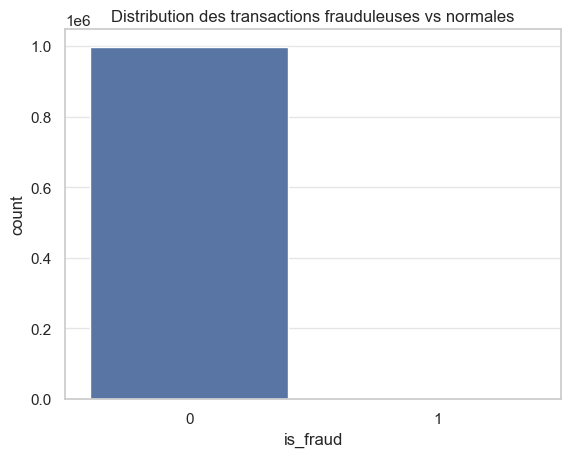

In [44]:
# Visualisation de la distribution
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x="is_fraud", data=df)
plt.title("Distribution des transactions frauduleuses vs normales")
plt.show()

Interprétation:

On note 3 000 transactions frauduleuses sur 1 000 000 (un taux de fraude de 0,3%).

2. Identifier les techniques de fraude les plus courantes

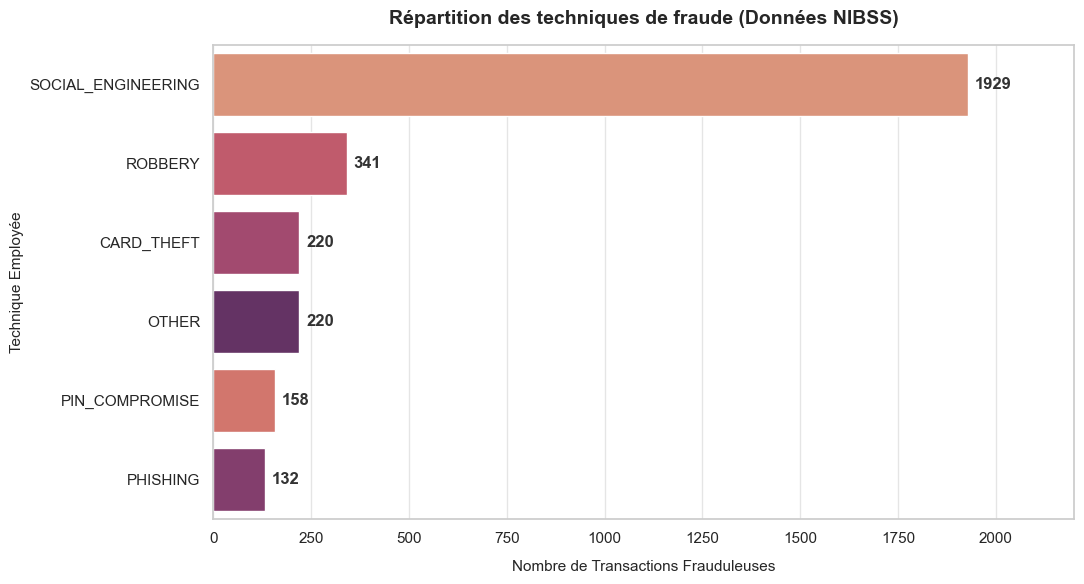

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration du style général
sns.set_theme(style="whitegrid")
plt.figure(figsize=(11, 6))

# Filtrer uniquement les fraudes et compter les techniques
fraud_data = df[df['is_fraud'] == 1]
order = fraud_data['fraud_technique'].value_counts().index

# Création du graphique
ax = sns.countplot(
    data=fraud_data,
    y='fraud_technique',
    order=order,
    hue='fraud_technique',
    palette='flare',
    legend=False
)

# Ajout des étiquettes de texte (les comptes exacts) au bout des barres
for container in ax.containers:
    ax.bar_label(container, padding=5, fontweight='bold', color='#333333')

# Personnalisation des titres et axes
plt.title("Répartition des techniques de fraude (Données NIBSS)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Nombre de Transactions Frauduleuses", fontsize=11, labelpad=10)
plt.ylabel("Technique Employée", fontsize=11)
plt.xlim(0, 2200) # Un peu d'espace pour le texte de la plus longue barre

plt.tight_layout()
plt.show()


    'SOCIAL_ENGINEERING': 'Ingénierie Sociale (Appels/SMS)',
    'ROBBERY': 'Extorsion / Braquage',
    'CARD_THEFT': 'Vol Physique de Carte',
    'OTHER': 'Autres techniques',
    'PIN_COMPROMISE': 'Code PIN Espionné / Compromis',
    'PHISHING': 'Phishing (Faux Sites/Emails)'

Interprétation:

Le graphique montre une domination de SOCIAL_ENGINEERING (environ 1 900 cas sur 3 000). C'est plus de 60% des fraudes.

Ce qui pourrait expliquer ce résultat : Au Nigeria et dans la sous-région, les attaquants n'utilisent pas forcément des failles techniques complexes. Ils manipulent les utilisateurs par téléphone ou messages (faux agents bancaires, usurpation d'identité, un SMS, un lien de phishing...) pour leur soutirer leurs codes. Ils sont communément appelés des arnaqueurs.

3. Analyser les canaux les plus à risque

In [46]:
# Taux de fraude par canal
fraud_par_canal = df.groupby('channel')['is_fraud'].mean().sort_values(ascending=False) * 100
print("--- Taux de fraude par Canal (%) ---")
print(fraud_par_canal)


--- Taux de fraude par Canal (%) ---
channel
Web       0.342664
Mobile    0.332798
POS       0.306052
IB        0.168585
ECOM      0.151313
ATM       0.109589
Name: is_fraud, dtype: float64


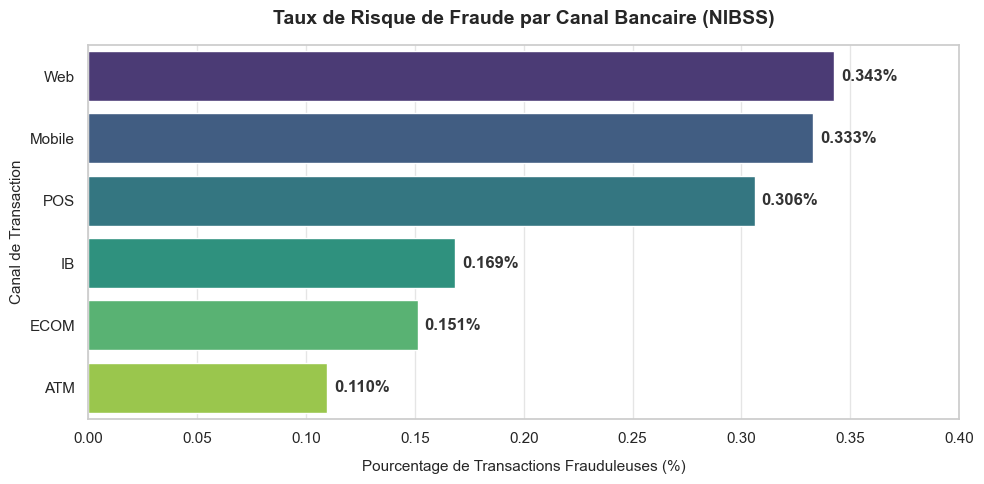

In [47]:
# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calcul du taux de fraude en % par canal
fraud_by_channel = (df.groupby('channel')['is_fraud'].mean() * 100).sort_values(ascending=False).reset_index()

# 2. Configuration du style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 5))

# 3. Création du graphique
ax = sns.barplot(
    data=fraud_by_channel,
    y='channel',
    x='is_fraud',
    hue='channel',
    palette='viridis',
    legend=False
)

# 4. Ajout du pourcentage exact au bout de chaque barre
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f%%', padding=5, fontweight='bold', color='#333333')

# 5. Personnalisation des titres et axes
plt.title("Taux de Risque de Fraude par Canal Bancaire (NIBSS)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Pourcentage de Transactions Frauduleuses (%)", fontsize=11, labelpad=10)
plt.ylabel("Canal de Transaction", fontsize=11)
plt.xlim(0, 0.40)
plt.tight_layout()
plt.show()


Interprétation:

On constate que les canaux numériques sont en première ligne. Le Web (0,34%) et le Mobile (0,33%) affichent les taux de fraude les plus élevés. Les distributeurs physiques (ATM) ferment la marche avec seulement (0,11%).

Ce qui pourrait expliquer ce résultat : La digitalisation rapide des services bancaires au Nigeria offre une surface d'attaque idéale sur le Web et les applications mobiles, tandis que sécuriser un guichet physique ou une carte à puce (ATM/POS) est devenu plus efficace au fil des années.

4. Faire une comparaison des montants légitime et frauduleux

In [48]:
print("--- Comparaison des montants (Naira) ---")
print(df.groupby('is_fraud')['amount'].describe())


--- Comparaison des montants (Naira) ---
             count           mean            std      min        25%  \
is_fraud                                                               
0         997000.0  156265.342062  323878.880310   168.55  27935.590   
1           3000.0  384958.685113  768443.530402  3673.30  87041.685   

                 50%         75%          max  
is_fraud                                       
0          66471.745  158931.470  10000000.00  
1         182012.175  386884.095  17926807.69  


Interprétation:

Le montant moyen (mean) d'une transaction légitime est de 156 265 Naira alors que la moyenne d'une fraude s'élève à 384 958 Naira. C'est plus du double.


Ce qui pourrait expliquer ce résultat : Une fois qu'un fraudeur prend le contrôle d'un compte (souvent via SOCIAL_ENGINEERING), il essaie de vider un maximum de fonds en un minimum de transactions avant que l'alerte ne soit donnée. Les valeurs maximales grimpent même jusqu'à 17,9 millions de Naira pour une seule fraude.

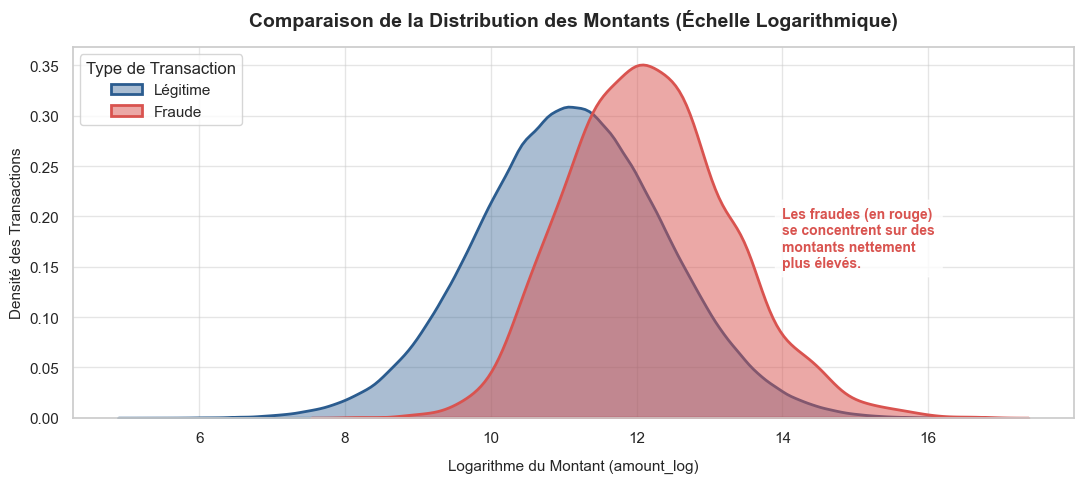

In [49]:
# Visualisation de la distribution avec Logarithme basée sur la colonne "amount_log "
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(11, 5))

# Tracé des courbes de densité pour les transactions légitimes et frauduleuses
sns.kdeplot(data=df[df['is_fraud'] == 0], x='amount_log', label='Légitime', fill=True, color='#2b5c8f', alpha=0.4, linewidth=2)
sns.kdeplot(data=df[df['is_fraud'] == 1], x='amount_log', label='Fraude', fill=True, color='#d9534f', alpha=0.5, linewidth=2)

# Personnalisation
plt.title("Comparaison de la Distribution des Montants (Échelle Logarithmique)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Logarithme du Montant (amount_log)", fontsize=11, labelpad=10)
plt.ylabel("Densité des Transactions", fontsize=11)
plt.legend(title="Type de Transaction", loc="upper left")

# Ajout d'une note explicative textuelle directement sur le graphique
plt.text(14, 0.15, "Les fraudes (en rouge)\nse concentrent sur des\nmontants nettement\nplus élevés.",
         fontsize=10, color='#d9534f', weight='semibold', bbox=dict(facecolor='white', alpha=0.8, boxstyle='round,pad=0.5'))

plt.tight_layout()
plt.show()


Interprétation:

Ce qui confirme et montre clairement que le montant des transactions frauduleuses est nettement supérieure à celui des transactions légitimes


**Matrice de corrélation**

In [50]:
# Sélectionner les colonnes numériques pour la matrice
numeric_cols = df.select_dtypes(include=['int64', 'float64', 'bool']).columns

# Sélectionner uniquement la colonne qui montre une forte corrélation avec la fraude (is_fraud) et trier par ordre décroissant
correlations = df[numeric_cols].corr()['is_fraud'].sort_values(ascending=False)

# Isoler le Top 8 des variables les plus corrélées (en excluant 'is_fraud' elle-même)
top_corr = correlations.drop('is_fraud').head(10)

print("--- Top 10 des variables les plus corrélées positivement avec la fraude ---")
print(top_corr)


--- Top 10 des variables les plus corrélées positivement avec la fraude ---
amount_log              0.044477
amount                  0.038324
month_sin               0.003174
is_weekend              0.001881
day_cos                 0.001844
day_of_week             0.001618
amount_rounded          0.001570
online_channel_ratio    0.001326
amount_std_total        0.000839
hour_cos                0.000832
Name: is_fraud, dtype: float64


Interprétation:

Les deux variables en tête sont amount_log et amount. Cela prouve que le montant d'argent en jeu est le premier signal unitaire.

Mais ces scores montrent qu'aucune variable n'a de relation linéaire directe avec la fraude. Si je fais une simple règle métier (ex: bloquer si le montant > X), je vais bloquer des milliers de clients honnêtes. C'est pour cela que l'utilisation d'un modèle d'arbre comme XGBoost est indispensable pour croiser ces faibles signaux entre eux


Les corrélations sont faibles.

Ça signifie probablement :

👉 la fraude n’est pas détectable par une seule variable

Mais par une combinaison de comportements

C’est exactement pourquoi :

Random Forest
XGBoost

vont probablement mieux fonctionner qu’une simple régression.

Une observation surprenante : aucune variable individuelle n’est fortement corrélée à la fraude. Les comportements frauduleux semblent émerger d’une combinaison complexe de signaux plutôt que d’un seul indicateur évident.

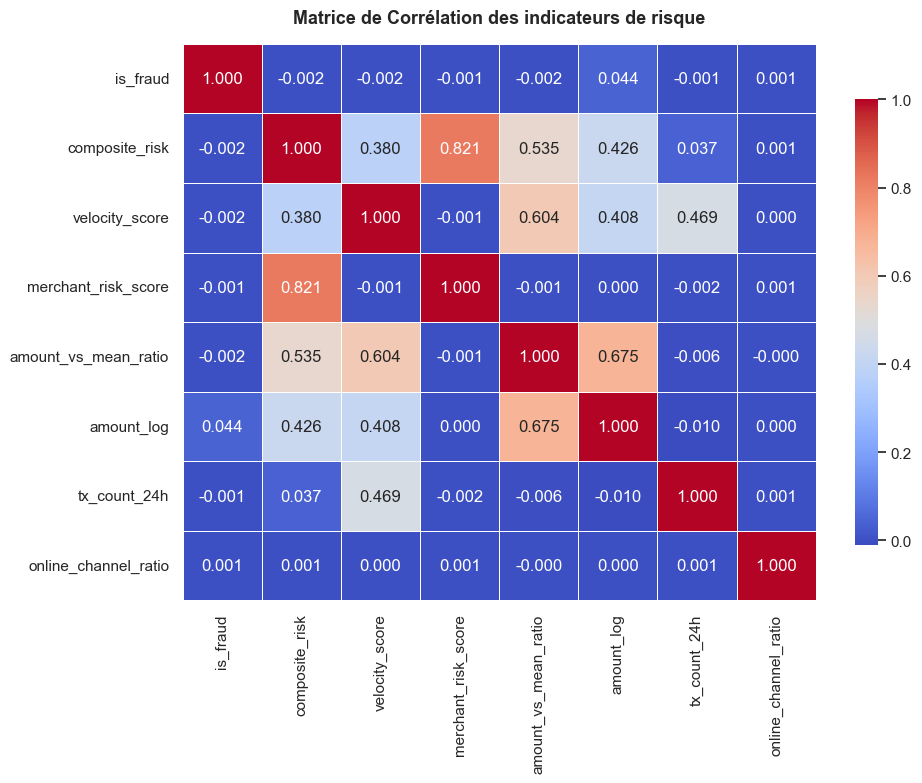

In [51]:
# Matrice de Corrélation (Heatmap)
import seaborn as sns
import matplotlib.pyplot as plt

# Sélection des features clés à analyser ensemble ( les variables qui représentent des indicateurs de risque et de comportement avancés)
features_cles = [
    'is_fraud', 'composite_risk', 'velocity_score', 'merchant_risk_score',
    'amount_vs_mean_ratio', 'amount_log', 'tx_count_24h', 'online_channel_ratio'
]

plt.figure(figsize=(10, 8))

# Calcul de la matrice réduite
matrix = df[features_cles].corr()

# Dessin de la heatmap
sns.heatmap(
    matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".3f",
    linewidths=.5,
    cbar_kws={"shrink": .8}
)

plt.title("Matrice de Corrélation des indicateurs de risque", fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()


Interprétation:

 Sur la première ligne de la matrice 'is fraud', la valeur la plus élevée est 0.044 pour amount_log. Toutes les autres variables (composite_risk, velocity_score, etc.) affichent des scores insignifiants de -0.001 ou -0.00

Aucune variable prise isolément n'a de relation en ligne droite avec la fraude. Si on essaie de bloquer la fraude en fixant juste une limite sur le montant ou sur le score de vélocité, on risque de bloquer des milliers de clients honnêtes pour rien. D'où l'utilisation d'un algorithme puissant comme XGBoost, capable de croiser plusieurs variables complexes en même temps.

Aussi on voit que:

composite_risk et merchant_risk_score (0.821) : C'est la corrélation la plus forte du graphique. Cela montre logiquement que le score de risque global d'une transaction dépend énormément du niveau de risque historique du commerçant (la boutique ou plateforme) où l'argent est dépensé.
Cela signifie que le modèle de la NIBSS considère que l'endroit où l'argent est dépensé est l'un des facteurs les plus importants pour définir si une transaction est suspecte ou non.


amount_vs_mean_ratio et amount_log (0.675) : Plus le montant de la transaction actuelle est élevé, plus le ratio par rapport aux dépenses habituelles du client explose. Cela montre une rupture brutale de comportement financier (c à d que d'un coup il dépense plus d'habitude).

velocity_score et amount_vs_mean_ratio (0.604) : Une accélération soudaine du nombre de transactions (fréquence de transactions) s'accompagne généralement de montants beaucoup plus élevés que d'habitude.


**Choix et Tests des modèles**

Séparation et Standardisation des données

In [52]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd

# 1. Sélection des variables catégorielles importantes à encoder
categorical_cols = ['channel', 'merchant_category', 'bank', 'location', 'age_group']

# 2. Application du One-Hot Encoding (convertit le texte en colonnes 0 et 1)
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True, dtype=int)

# 3. Suppression des IDs restants et des cibles
columns_to_drop = ['transaction_id', 'customer_id', 'timestamp', 'is_fraud', 'fraud_technique']
X = df_encoded.drop(columns=columns_to_drop)
y = df_encoded['is_fraud']

# 4. Découpage Train/Test avec stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 5. Standardisation (sur TOUTES les colonnes y compris les encodées)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Structure après encodage : {X.shape[1]} colonnes au total.")


Structure après encodage : 63 colonnes au total.


In [53]:
X

,amount,hour,day_of_week,month,is_weekend,is_peak_hour,tx_count_24h,amount_sum_24h,amount_mean_7d,amount_std_7d,...,bank_Wema,bank_Zenith,location_Lagos,location_Ogun,location_Other,location_Oyo,location_Rivers,age_group_30-39,age_group_40+,age_group_<20
0,32266.83,4,5,1,True,False,1.0,32266.83,32266.830000,0.000000,...,0,0,0,0,1,0,0,1,0,0
1,72530.49,11,1,1,False,True,1.0,72530.49,52398.660000,20131.830000,...,0,0,0,0,1,0,0,1,0,0
2,168152.87,2,6,1,True,False,1.0,168152.87,120341.680000,47811.190000,...,1,0,0,0,1,0,0,1,0,0
3,16439.93,8,1,1,False,False,1.0,16439.93,85707.763333,62633.507753,...,0,0,0,0,1,0,0,1,0,0
4,9922.68,15,2,2,False,True,1.0,9922.68,9922.680000,0.000000,...,0,0,0,0,1,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,30582.37,11,1,12,False,True,1.0,30582.37,62676.130000,51260.627172,...,0,0,0,0,1,0,0,0,1,0
999996,37129.26,10,6,12,True,True,1.0,37129.26,33855.815000,3273.445000,...,0,0,0,0,1,0,0,0,1,0
999997,20093.53,10,6,12,True,True,2.0,57222.79,29268.386667,7016.596436,...,0,0,0,0,1,0,0,0,1,0
999998,183070.82,11,6,12,True,True,3.0,240293.61,67718.995000,66875.050002,...,0,0,0,0,1,0,0,0,1,0


In [54]:
X.columns

Index(['amount', 'hour', 'day_of_week', 'month', 'is_weekend', 'is_peak_hour',
       'tx_count_24h', 'amount_sum_24h', 'amount_mean_7d', 'amount_std_7d',
       'tx_count_total', 'amount_mean_total', 'amount_std_total',
       'channel_diversity', 'location_diversity', 'amount_vs_mean_ratio',
       'online_channel_ratio', 'hour_sin', 'hour_cos', 'day_sin', 'day_cos',
       'month_sin', 'month_cos', 'amount_log', 'amount_rounded',
       'velocity_score', 'merchant_risk_score', 'composite_risk',
       'channel_ECOM', 'channel_IB', 'channel_Mobile', 'channel_POS',
       'channel_Web', 'merchant_category_Airtime',
       'merchant_category_Bill_Payment', 'merchant_category_Education',
       'merchant_category_Electronics', 'merchant_category_Entertainment',
       'merchant_category_Fashion', 'merchant_category_Fuel',
       'merchant_category_Grocery', 'merchant_category_Medical',
       'merchant_category_Restaurant', 'merchant_category_Retail',
       'merchant_category_Transfer'

In [55]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# ENTRAÎNEMENT DU MODÈLE

# max_iter=1000 permet de donner assez de temps au modèle pour calculer
# class_weight='balanced' force le modèle à accorder de l'importance aux 0.3% de fraude
model_lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

# On entraîne le modèle sur les données d'entraînement standardisées
model_lr.fit(X_train_scaled, y_train)

# Prédictions sur le jeu de test

y_pred_lr = model_lr.predict(X_test_scaled)


In [56]:
# ÉVALUATION DU MODÈLE

# Calcul de l'Accuracy Globale

accuracy = accuracy_score(y_test, y_pred_lr)
print(f"Accuracy Score global : {accuracy:.2f}")

#Rapport complet (Précision, Rappel, F1-score)
print("\nRapport de Classification Complet :")
print(classification_report(y_test, y_pred_lr))

Accuracy Score global : 0.70

Rapport de Classification Complet :
              precision    recall  f1-score   support

           0       1.00      0.70      0.83    199400
           1       0.01      0.70      0.01       600

    accuracy                           0.70    200000
   macro avg       0.50      0.70      0.42    200000
weighted avg       1.00      0.70      0.82    200000



L'Accuracy globale (0.70) veut dire que le modèle a raison dans 70% des cas au global.

Alors que si le modèle avait simplement dit "Toutes les transactions sont normales" sans réfléchir, il aurait obtenu (99,7%) d'accuracy (car les fraudes ne représentent que 0,3% des données). Une accuracy de 70% est donc techniquement un échec dû au déséquilibre des classes.

Le Rappel de la fraude (Recall de la classe 1 = (0.70) veut dire que sur les 600 vraies fraudes qui se cachaient dans le jeu de test, le modèle en a intercepté 70%. C'est une bonne performance

La Précision de la fraude (Precision de la classe 1 = (0.01) soit 1%) veut dire que lorsque le modèle envoie une alerte de fraude, il n'a raison que 1% du temps.

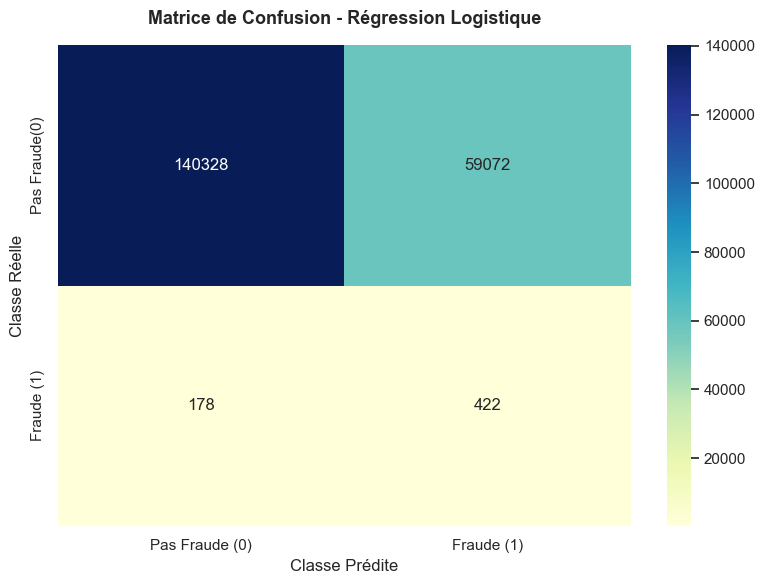

In [57]:
 # matrice de confusion
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(8, 6))

sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu',
            xticklabels=['Pas Fraude (0)', 'Fraude (1)'],
            yticklabels=['Pas Fraude(0)', 'Fraude (1)'])

plt.title("Matrice de Confusion - Régression Logistique", fontsize=13, fontweight='bold', pad=15)
plt.ylabel("Classe Réelle")
plt.xlabel("Classe Prédite")

plt.tight_layout()
plt.show()


**Interprétation**

(140328) (Vrais Négatifs) : Le modèle a correctement validé ces transactions légitimes. Les clients ont pu payer sans problème.

(422) (Vrais Positifs) : Le modèle a brillamment détecté ces vraies fraudes. C'est de l'argent sauvé pour la banque.

(178) (Faux Négatifs) : Le modèle a laissé passer (178) fraudes sans les voir. Les fraudeurs ont vidé les comptes de ces clients.

(59072) (Faux Positifs) : C'est le chiffre catastrophe. Le modèle a bloqué par erreur (59072) clients honnêtes en pensant qu'ils fraudaient.

En conclusion, La Régression Logistique attrape bien la fraude, mais au prix inacceptable de (59072) clients bloqués par erreur. Donc pour affiner la frontière et détruire ces faux positifs, on va  devoir utiliser des structures d'arbres

# RANDOM FOREST

In [26]:
from sklearn.ensemble import RandomForestClassifier

# ENTRAÎNEMENT DU MODÈLE

model_rf = RandomForestClassifier(
    class_weight='balanced',  #  gère le déséquilibre
    n_estimators=50,  #50 arbres
    max_depth=6, # profondeur limitée
    random_state=42,
    n_jobs=-1   # utilise tous les cœurs de votre processeur pour accélérer le calcul
)

model_rf.fit(X_train_scaled, y_train)

#  Prédictions sur le jeu de test

y_pred_rf = model_rf.predict(X_test_scaled)

# ÉVALUATION DU MODÈLE

# Accuracy
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"Accuracy Score global : {accuracy_rf:.2f}")

# Classification Report
print("\nRapport de Classification Complet :")
print(classification_report(y_test, y_pred_rf))


Accuracy Score global : 0.82

Rapport de Classification Complet :
              precision    recall  f1-score   support

           0       1.00      0.82      0.90    199400
           1       0.01      0.78      0.03       600

    accuracy                           0.82    200000
   macro avg       0.51      0.80      0.46    200000
weighted avg       1.00      0.82      0.90    200000



L'Accuracy globale (0.82 soit 82%) : Elle grimpe de 70% à 82%. Le modèle est globalement beaucoup plus robuste.

Le Rappel (Recall de la classe 1 = 0.78 soit 78%) : Le modèle capte désormais 78% des fraudes existantes. C'est une excellente performance sur un dataset aussi déséquilibré.

La Précision (Precision de la classe 1 = 0.01 soit 1%) : La précision reste bloquée à 1% (0.01) à cause du volume massif de transactions saines par rapport aux fraudes, mais le F1-score triple (il passe de 0.01 à 0.03).

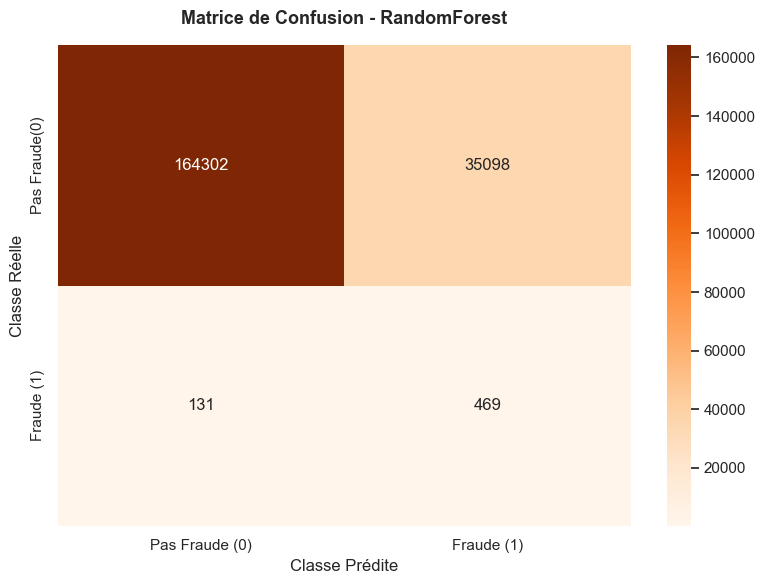

In [27]:
#  Matrice de confusion

plt.figure(figsize=(8, 6))
cm_rf = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Pas Fraude (0)', 'Fraude (1)'],
            yticklabels=['Pas Fraude(0)', 'Fraude (1)'])

plt.title("Matrice de Confusion - RandomForest", fontsize=13, fontweight='bold', pad=15)
plt.ylabel("Classe Réelle")
plt.xlabel("Classe Prédite")

plt.tight_layout()
plt.show()


Les Vrais Positifs (469) : Le Random Forest fait mieux . Il intercepte 469 fraudes sur 600 (contre 422 pour la régression logistique). C'est plus d'argent récupéré pour la banque nigériane.

Les Faux Négatifs (131) : Le nombre de fraudes ratées baisse (131 contre 178 auparavant). La banque est mieux protégée.

Les Faux Positifs (35 098) : C'est la grande victoire de cette étape. On est passé de 59 072 clients bloqués par erreur à 35 098.

Même si le Random Forest a éliminé plus de faux positifs, bloquer 35 000 clients honnêtes reste encore trop élevé pour une mise en production réelle.C'est là que XGBoost entre en scène. Au lieu de construire des arbres indépendants en parallèle (comme le Random Forest), XGBoost construit ses arbres les uns après les autres, chaque nouvel arbre ayant pour mission unique de corriger les erreurs de prédiction (notamment les faux positifs) de l'arbre précédent.

# XGBoost

In [28]:

from xgboost import XGBClassifier

# ENTRAÎNEMENT DU MODÈLE

model_xgb = XGBClassifier(
    scale_pos_weight=333,   # scale_pos_weight = ratio (Total classe 0 / Total classe 1) -> 997000 / 3000 ≈ 333
    max_depth=6, # la profondeur maximale des arbres
    n_estimators=100,  # le nombre d'arbres
    learning_rate=0.1,  # la vitesse d'apprentissage
    eval_metric='logloss', #  métrique d'évaluation pour le modèle lui meme
    random_state=42, # pour reproduire le meme résultat à chaque fois qu'on exécute
    n_jobs=-1
)

model_xgb.fit(X_train_scaled, y_train)

# Prédictions sur le jeu de test

y_pred_xgb = model_xgb.predict(X_test_scaled)

# ÉVALUATION DU MODÈLE

# Accuracy
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
print(f"Accuracy Score global : {accuracy_xgb:.2f}")

# Classification Report
print("\nRapport de Classification Complet :")
print(classification_report(y_test, y_pred_xgb))


Accuracy Score global : 1.00

Rapport de Classification Complet :
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    199400
           1       0.77      0.82      0.79       600

    accuracy                           1.00    200000
   macro avg       0.89      0.91      0.90    200000
weighted avg       1.00      1.00      1.00    200000



La Précision (0.77 soit 77%) : Votre précision fait un bond de géant de 1% à 77%. Désormais, quand XGBoost déclenche une alerte de fraude, la banque a raison près de 8 fois sur 10.

Le F1-Score (0.79 soit 79%) : Ce score résume parfaitement la performance. Vous avez un équilibre quasi parfait entre une haute sécurité (détecter la fraude) et une expérience utilisateur fluide (ne pas bloquer pour rien).

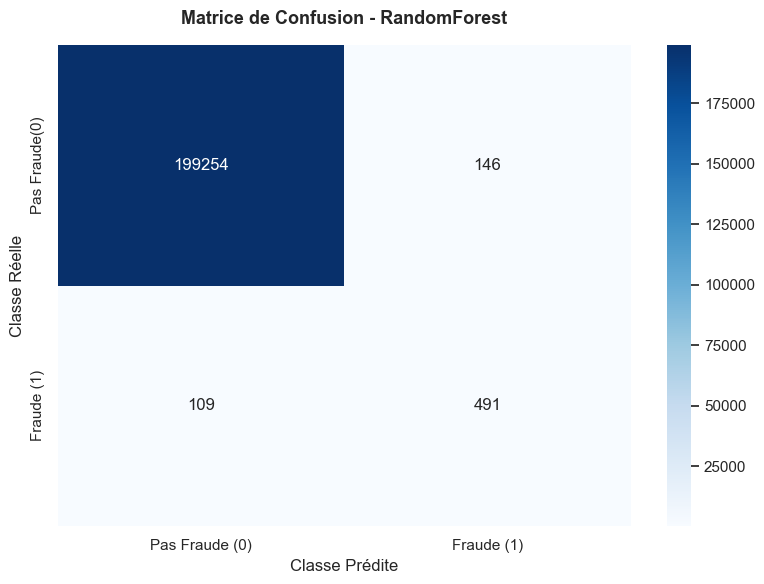

In [29]:
#  Matrice de confusion

plt.figure(figsize=(8, 6))

cm_xgb = confusion_matrix(y_test, y_pred_xgb)
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pas Fraude (0)', 'Fraude (1)'],
            yticklabels=['Pas Fraude(0)', 'Fraude (1)'])

plt.title("Matrice de Confusion - RandomForest", fontsize=13, fontweight='bold', pad=15)
plt.ylabel("Classe Réelle")
plt.xlabel("Classe Prédite")

plt.tight_layout()
plt.show()

Les Faux Positifs (146) : C'est le chef-d'œuvre du modèle. On est passé de 59 072 (Régression Logistique) puis 35 098 (Random Forest) à seulement 146 clients bloqués par erreur. XGBoost a quasiment réduit à néant le risque de fausses alertes pour les clients honnêtes de la NIBSS.

Les Vrais Positifs (491) : Le modèle intercepte 491 fraudes sur 600 (82% de réussite), soit le meilleur score des trois algorithmes testés.


**Pourquoi XGBoost a-t-il si facilement écrasé les autres ?**

L'apprentissage séquentiel (Boosting) : Le Random Forest créait des arbres en parallèle sans qu'ils ne se parlent. XGBoost a analysé les faux positifs du Random Forest et a construit ses arbres suivants avec l'unique mission de corriger ces erreurs spécifiques.

La puissance de scale_pos_weight : En donnant le ratio exact de 333, XGBoost a su accorder l'importance nécessaire à la fraude sans pour autant devenir paranoïaque comme la Régression Logistique.

In [30]:
X.columns

Index(['amount', 'hour', 'day_of_week', 'month', 'is_weekend', 'is_peak_hour',
       'tx_count_24h', 'amount_sum_24h', 'amount_mean_7d', 'amount_std_7d',
       'tx_count_total', 'amount_mean_total', 'amount_std_total',
       'channel_diversity', 'location_diversity', 'amount_vs_mean_ratio',
       'online_channel_ratio', 'hour_sin', 'hour_cos', 'day_sin', 'day_cos',
       'month_sin', 'month_cos', 'amount_log', 'amount_rounded',
       'velocity_score', 'merchant_risk_score', 'composite_risk',
       'channel_ECOM', 'channel_IB', 'channel_Mobile', 'channel_POS',
       'channel_Web', 'merchant_category_Airtime',
       'merchant_category_Bill_Payment', 'merchant_category_Education',
       'merchant_category_Electronics', 'merchant_category_Entertainment',
       'merchant_category_Fashion', 'merchant_category_Fuel',
       'merchant_category_Grocery', 'merchant_category_Medical',
       'merchant_category_Restaurant', 'merchant_category_Retail',
       'merchant_category_Transfer'

**Initialisation du calcul SHAP (Nettoyage et Échantillonnage)**

In [31]:
import shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# On recrée le DataFrame Pandas à partir des données de test standardisées pour pouvoir utiliser .sample()

X_test_df = pd.DataFrame(X_test_scaled, columns=X_train.columns)

# On remplace le caractère au niveau des noms des colonnes (age_group_<20) '<' par 'under_' pour apaiser XGBoost
X_test_df.columns = X_test_df.columns.str.replace('<', 'under_')

# On extrait notre échantillon de 1 000 transactions nettoyées
X_sample = X_test_df.sample(n=1000, random_state=42)

# Création de l'Explainer SHAP dédié aux modèles d'arbres et affectation à notre modèle xgb
explainer = shap.TreeExplainer(model_xgb)

# Calcul des valeurs SHAP sur notre échantillon
shap_values = explainer(X_sample)

# C'est le rapport d'enquête final. Il contient une note (positive ou négative) pour chaque variable de chaque transaction sur notre échantillon.

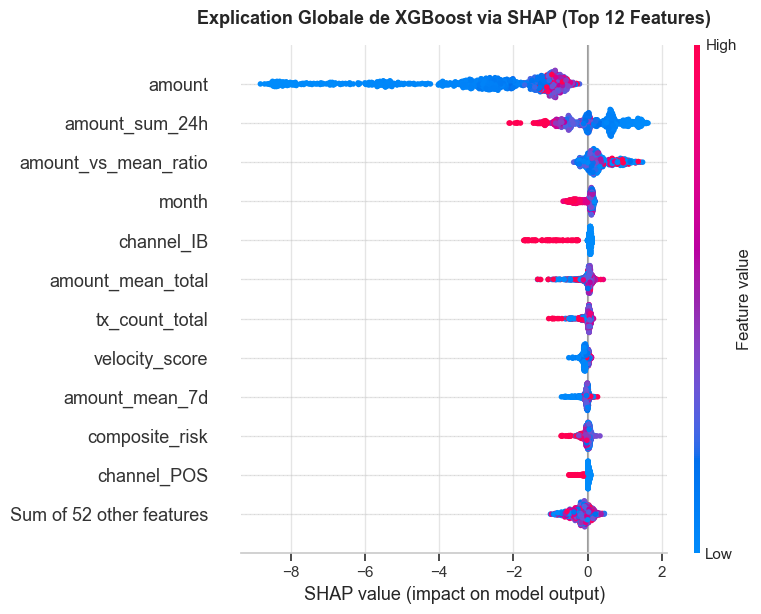

In [32]:
# Configuration de la taille du graphique
plt.figure(figsize=(10, 6))

# Génération du Beeswarm plot (graphique en essaim d'abeilles)
# Il montre l'impact de chaque feature sur la décision finale
shap.plots.beeswarm(shap_values, max_display=12, show=False)

plt.title("Explication Globale de XGBoost via SHAP (Top 12 Features)", fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()


**Le Top 3 des facteurs de décision de XGBoost**

amount : Le montant de la transaction actuelle est, de loin, la variable la plus puissante du modèle.

amount_sum_24h : Le cumul des montants dépensés par le client au cours des dernières 24 heures.

amount_vs_mean_ratio : Le ratio entre la transaction actuelle et la moyenne historique du client.

En conclusion XGBoost s'appuie massivement sur des signaux financiers et comportementaux immédiats pour traquer la fraude bancaire plutôt que sur des facteurs fixes comme la banque ou l'âge.